In [1]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense,Conv2D,MaxPooling2D, GRU
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
import scipy.ndimage

In [2]:
upload =files.upload()
stock_data = pd.read_csv(io.BytesIO(upload['close price-case study II.csv']))
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
0,20251022,526,2739,4865,2031,16900,9200,4992,20450,5580,8670,536,1975,142610,484,7870
1,20251021,518,2712,4762,1972,16920,9230,4977,20500,5430,8570,534,1918,139030,484,7820
2,20251020,529,2754,4645,2010,17010,9240,4968,20440,5460,8490,520,1884,135800,494,7800
3,20251019,517,2816,4721,2042,17220,9270,4960,20480,5580,8590,510,1906,131940,499,7920
4,20251018,517,2791,4649,2014,17180,9310,4949,20410,5630,8550,521,1898,128170,485,7740


In [3]:
stock_data = stock_data.sort_values(by='Date', ascending= True)
stock_data.head()

,Date,Iran Khodro,S*Mobarakeh Steel,S*Isf. Oil Ref.Co.,Gol-E-Gohar.,S*F. & Kh. Cement,Rouz Darou P.,Pars Switch,Iran China Clay,S*IRI Marine Co.,I. Pegah Dairy,Int. Const.,S*Sabet Khorasan,Soufian Cement,S*Saipa,S*I. N. C. Ind.
1677,20181022,2685,6219,10845,8269,1592,2250,5991,11934,4995,9478,1062,3568,3454,1144,4579
1676,20181023,2587,6082,10845,7952,1530,2193,5990,11512,4859,9476,1045,3391,3454,1090,4472
1675,20181024,2526,5989,10002,7780,1460,2162,5953,11119,4641,9476,996,3224,3454,1036,4364
1674,20181027,2418,5959,9606,7791,1388,2059,5959,10869,4614,9466,969,3065,3453,1045,4286
1673,20181028,2451,5956,9467,7878,1344,2119,5948,10610,4639,9454,966,3173,3393,1080,4302


In [4]:
num_columns=stock_data.shape[1]
num_rows=stock_data.shape[0]
raw_prices = np.zeros((num_rows,num_columns-1))
for i in range(1,num_columns,1):
  for j in range(0,num_rows):
     raw_prices[j,i-1] = stock_data.iloc[j,i]

In [5]:
Relative_difference = np.zeros((num_columns-1,num_rows -1))
for i in range(num_columns-1):
  for j in range(num_rows-1):
        Relative_difference[i,j] =(raw_prices[j+1,i]- raw_prices[j,i])/raw_prices[j,i]

In [6]:
clean_RD =[]
jump_index=[]
num_jump = []
for i in range(num_columns-1):
  clean_RD.append([])
  jump_index.append([])
  k=0
  for j in range(len(Relative_difference[i])):
    if abs(Relative_difference[i][j]) >= 0.1 or abs(Relative_difference[i][j]) <= 0.00000000000000001:
      jump_index[i].append(j)
      k+= 1
      j+=1
    else:
      clean_RD[i].append(Relative_difference[i][j])
  num_jump.append(k)

In [7]:
clean_prices = []
for i in range(num_columns-1):
    clean_prices.append([])
    new_lenghth = len(Relative_difference[i])-num_jump[i]
    #print(new_lenghth)
    p = np.zeros(new_lenghth+1)
    p[0] = raw_prices[0,i]
    for l in range(1,new_lenghth+1):
        p[l] = p[l-1]*(1+clean_RD[i][l-1])
    clean_prices[i].append(p)

In [8]:
def remove_nan_element (vector):
  non_nan_indices = ~np.isnan(vector)
  vector_without_nan = vector[non_nan_indices]
  return vector_without_nan

#Separate the last_90_ for prediction
last_90_RD_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
  vector_without_nan=(remove_nan_element(np.array(clean_RD[i])))
  last_90_RD_clean[:,i] = vector_without_nan[-90:]


#Separate the last_90_ for Plt
last_90_prices_clean =np.zeros((90,num_columns-1))
for i in range (num_columns-1):
   vector_without_nan=(remove_nan_element(clean_prices[i][0]))
   last_90_prices_clean[:,i] = vector_without_nan[-90:]

In [9]:
#Relative_difference without the last 90 days
train_RD_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(np.array(clean_RD[i]))
   train_RD_clean.append(vector_without_nan[:-90])

# close price without the last 90 days
train_prices_clean = []
for i in range (num_columns-1):
   vector_without_nan=remove_nan_element(clean_prices[i][0])
   train_prices_clean.append(vector_without_nan[:-90])

In [10]:
def split_to_squenses(data,step,future):
   X, Y = [], []
   for i in range(len(data)-step-future):
     d=i+step
     X.append(data[i:d])
     Y.append(data[d:(d+future)])
   return np.array(X), np.array(Y)

In [11]:
from random import choices
def bootstraping(xtrain, nboot):
  indexes = []
  length = xtrain.shape[0]
  indices = list(range(1, length))
  for i in range(nboot):
    boot = choices(indices, k = length)
    indexes.append(boot)
  return indexes

In [12]:
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Reshape

def create_CNN_model(x_train,y_train):
   

        model = Sequential([
        # --- Block 1 ---
        Conv1D(8, kernel_size=5, activation='relu', padding='same',
               input_shape=(x_train.shape[1], x_train.shape[2])),
        #BatchNormalization(),
        Reshape((x_train.shape[1],8,1)),
        # --- Block 2 ---
        Conv2D(4, kernel_size= (3,8), activation='relu', padding='valid'),
        #Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        #BatchNormalization(),
        #Dropout(0.1),

        # --- Bottleneck ---
        #GlobalMaxPooling1D(),
        MaxPooling2D(pool_size = 3, padding='same'),
        Flatten(), 
        Dropout(0.1),
        # --- Dense Layers ---
        #Dense(64, activation='relu'),
        Dense(90)
        ])

        model.compile(
          optimizer=Adam(learning_rate=5e-4),
          loss='huber',
          metrics=['mse']
        )

        return model

In [13]:
#!pip install openpyxl

In [14]:
# We create indices for 35 scenarios and then you choose 5, 10, 15, 20, 25 , 30 and 35 scenarios from that.
#for i,share in enumerate(train_RD_clean):
#  x_train,y_train = split_to_squenses(share,900,90)
#  df_index = pd.DataFrame(bootstraping(x_train,35))
#  filepath = f'E:/desktop/javadi-soleimani/15 assets/indexes_35/inds {i}.xlsx'
#  df_index.to_excel(filepath, index=False)

In [15]:
# Download once and use it for everyone.
#!zip -r /content/all_results_gru.zip /content
#from google.colab import files
#files.download("/content/all_results_gru.zip")

In [16]:
inds = []
for sh in range(num_columns-1):
  upload =files.upload()
  inds.append(pd.read_excel(io.BytesIO(upload[f'inds {sh}.xlsx'])))

In [18]:
nboot = 35  # number of Scenarios

In [19]:
#prediction_y_not_boot2 = []
#prediction_y_boot2 = []
#num_assets = 15
#for index in range(num_assets):
#  prediction_y_not_boot2.append([np.array(pd.read_excel(f'Prediction_not_boot2 {index+1}.xlsx')).reshape((90,))])
#  prediction_y_boot2.append([])
#  for b in range(nboot):
#    prediction_y_boot2[index].append([np.array(pd.read_excel(f'Prediction2 {index+1}{b+1}.xlsx')).reshape((90,))])

In [20]:
import warnings
history_boot2 = []
prediction_y_not_boot2 = []
history_not_boot2 = []
prediction_y_boot2 = []
model2 = []
modelb2 = []
cntr1 = 0
for index,share in enumerate(train_RD_clean):
  cntr2 = 0
  print("property",cntr1+1)
  x_train,y_train = split_to_squenses(share,900,90)
  x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
  length = len(train_RD_clean[cntr1])
  x_test = train_RD_clean[cntr1][(length - 900):length]
  x_test = np.reshape(x_test, (1, len(x_test), 1))
  model2.append(create_CNN_model(x_train,y_train))
  warnings.filterwarnings("ignore")
  fited = model2[cntr1].fit(x_train, y_train, epochs=100, batch_size=100, shuffle=False,verbose=0)
  history_not_boot2.append(fited)
  warnings.filterwarnings("ignore")
  yy = model2[cntr1].predict(x_test)
  yy_array = np.array(yy)
#  df_PNB = pd.DataFrame(yy_array)
#  filepath = f'Prediction_not_boot2 {index+1}.xlsx'
#  df_PNB.to_excel(filepath, index=False)
  prediction_y_not_boot2.append(yy)
  modelb2.append([])
  history_boot2.append([])
  prediction_y_boot2.append([])
  for b in range(nboot):
    print("bootstrap",cntr2+1)
    indx = np.asarray(inds[cntr1])[b,:]
    x_boot = x_train[indx,:]
    y_boot = y_train[indx,:]
    modelb2[cntr1].append(create_CNN_model(x_boot,y_boot))
    warnings.filterwarnings("ignore")
    fited = modelb2[cntr1][cntr2].fit(x_boot, y_boot, epochs=100, batch_size=100, shuffle=False,verbose=0)
    history_boot2[cntr1].append(fited)
    warnings.filterwarnings("ignore")
    yy = modelb2[cntr1][cntr2].predict(x_test)
    yy_array = np.array(yy)
#    df_PB = pd.DataFrame(yy_array)
#    filepath = f'Prediction2 {index+1}{b+1}.xlsx'
#    df_PB.to_excel(filepath, index=False)
    prediction_y_boot2[cntr1].append(yy)
    cntr2 = cntr2 + 1
  cntr1 = cntr1 + 1

In [21]:
#for sh in range(0,9):
#  filepath = f'inds {sh}.xlsx'
#  df1 = pd.DataFrame(inds[sh])
#  df1.to_excel(filepath,index=False)

In [22]:
#for sh in range(9):
#  inds[sh] = np.asarray(inds[sh])
#  print(inds[sh].shape)

In [23]:
#!zip -r /content/all_results_gru.zip /content
#from google.colab import files
#files.download("/content/all_results_gru.zip")
#prediction_y_not_boot2[0][0].shape, last_90_RD_clean[:,0].shape

In [24]:
num_assets = 15
for i in range(num_assets):
   print('mse for without bootstrap asset',i, '=')
   print(sum((prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])**2))
   print('mae for without bootstrap asset',i, '=')
   print(sum(abs(prediction_y_not_boot2[i][0] - last_90_RD_clean[:,i])))

mse for without bootstrap asset 0 =
0.0485216702771267
mae for without bootstrap asset 0 =
1.8605843471163916
mse for without bootstrap asset 1 =
0.060162332304199
mae for without bootstrap asset 1 =
1.8259513224626804
mse for without bootstrap asset 2 =
0.048578712448211506
mae for without bootstrap asset 2 =
1.7221603343916285
mse for without bootstrap asset 3 =
0.03436821139336262
mae for without bootstrap asset 3 =
1.431218438229878
mse for without bootstrap asset 4 =
0.051298512148735015
mae for without bootstrap asset 4 =
1.787366542113803
mse for without bootstrap asset 5 =
0.0167228816074872
mae for without bootstrap asset 5 =
0.8905084578135094
mse for without bootstrap asset 6 =
0.01346918572702697
mae for without bootstrap asset 6 =
0.7895353517864809
mse for without bootstrap asset 7 =
0.03309793896331336
mae for without bootstrap asset 7 =
1.2515194758640151
mse for without bootstrap asset 8 =
0.05479529749036887
mae for without bootstrap asset 8 =
1.9062138820749812
mse f

In [25]:
num_assets = 15
price_prediction_not_boot2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros(90)
    p[0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
    for k in range(1,90):
        p[k] = p[k-1]*(1+prediction_y_not_boot2[i][0][k-1])
    price_prediction_not_boot2.append(p)

In [26]:
price_prediction2 = []
#for i in range(num_columns-1):
for i in range(num_assets):
    p = np.zeros((nboot,90))
    for j in range(nboot):
        p[j,0] = train_prices_clean[i][len(Relative_difference[1])-num_jump[i]-90]
        for k in range(1,90):
            p[j,k] = p[j,k-1]*(1+prediction_y_boot2[i][j][0][k-1])
    price_prediction2.append(p)

In [27]:
numboot = 35 # برای 10و15و20و25 جداگانه انجام شود
for i in range(num_assets):
  end = len(train_prices_clean[i])
  beg = end - 90
  time = range(len(train_prices_clean[i][beg:end]))
  plt.plot(time,train_prices_clean[i][beg:end],color="black")
  tim = range(len(train_prices_clean[i][beg:end])-1,len(train_prices_clean[i][beg:end])+90)
  for j in range(0,numboot):
    a = np.hstack([train_prices_clean[i][end-1],price_prediction2[i][j][:]])
    plt.plot(tim, a, color = 'lightblue', linestyle='dashed', linewidth=1)
  b = np.hstack([train_prices_clean[i][end-1],last_90_prices_clean[:,i]])
  plt.plot(tim,b,color = "red", linewidth=1)
  c = np.hstack([train_prices_clean[i][end-1],price_prediction_not_boot2[i][:]])
  plt.plot(tim,c,color = "green", linewidth=1)
  plt.savefig(f'stock_c_{i+1}_{numboot}.jpg')
  plt.show()
  #files.download(f'stock_g {i+1}_{numboot}.jpg')

In [28]:
def calculate_mean_cov(y_pred, nboot):
  mean = np.zeros((nboot, num_assets))
  std = np.zeros((nboot,num_assets))
  for i in range(num_assets):
    for j in range(nboot):
      mean[j,i] = np.mean(y_pred[i][j])
      std [j,i] = np.std(y_pred[i][j])
  Covariance_Matrix = np.zeros((nboot,num_assets,num_assets))
  for j in range(nboot):
    Cov_between = np.array([y_pred[i][j] for i in range(num_assets)])
    CC= Cov_between.reshape(Cov_between.shape[0], Cov_between.shape[2])
    Covariance_Matrix[j,:,:] = np.cov(CC)
  return mean, std, Covariance_Matrix

nboot = 35
m2_30, s2_30, c2_30 = calculate_mean_cov(prediction_y_boot2,nboot)


In [29]:
#dfm2 = pd.DataFrame(m2)
## save to xlsx file
#filepath = 'm2.xlsx'
#dfm2.to_excel(filepath, index=False)
#files.download('m2.xlsx')
#dfs2 = pd.DataFrame(s2)
#filepath = 's2.xlsx'
#dfs2.to_excel(filepath, index=False)

#for j in range(15):
#  dfc2 = pd.DataFrame(c2[j,:,:])
#  filepath = f'c2 {j+1}.xlsx'
#  dfc2.to_excel(filepath, index=False)
#  files.download(filepath)

In [30]:
#!pip install cvxopt

In [31]:
#!pip install scipy

In [32]:
#!pip install xlrd

In [33]:
import numpy as np
from scipy.optimize import minimize , Bounds
from cvxopt import matrix, solvers
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
#from google.colab import files
import os
import io
import xlrd

In [35]:
Mean30 = m2_30
covariance30 = []
for i in range(nboot):
  covariance30.append(c2_30[i,:,:])

In [37]:
MEAN30 = []
for i in range (nboot):
    Mean_row30 =np.zeros((1,num_assets))
    Mean_row30[0,:] = Mean30[i,:]
    MEAN30.append(Mean_row30)

In [38]:
import random

In [ ]:
#Senario_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
Optimal_value30 =[]
Optimal_solution30 =[]
for i in range(nboot):
  sigma = covariance30[i]
  Q = matrix(sigma, tc='d')
  P = matrix(-MEAN30[i], tc='d').T
  G = matrix(-np.eye(num_assets), tc='d')
  h = matrix(np.zeros(num_assets), tc='d')
  A = matrix(np.ones(num_assets), tc='d').T
  b = matrix(1.0)
  Optimal_value_Lambda = []
  Optimal_solution_Lambda = []
  for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]: 
      sol = solvers.qp(2*Lambda*Q,(1-Lambda)*P,G,h,A,b)
      Optimal_value_Lambda.append(sol['primal objective'])
      Optimal_solution_Lambda.append(sol['x'])
  Optimal_solution30.append(Optimal_solution_Lambda)
  Optimal_value30.append(Optimal_value_Lambda)
solvers.options.update(old_settings)

In [40]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for j in range(nboot):
   print("Bootstrap sample",j+1)
   for i in range(9):
    print("lambda =", Lambda_list[i])
    print(Optimal_solution30[j][i][:])

In [41]:
OPT_X =[]
for l in range(nboot):
  OX =np.zeros((num_assets,num_assets))
  for n in range(9):
    for k in range(num_assets):
      OX[k,n]=Optimal_solution30[l][n][k]
  OPT_X.append(OX)

In [42]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(nboot):
  print("Bootstrap sample",i+1)
  sigma = covariance30[i]
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    a = np.dot(OPT_X[i][:,k].T, sigma @ OPT_X[i][:,k])
    print(a)

In [43]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for m in range(nboot):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    u = np.dot(MEAN30[m], OPT_X[m][:,k])
    print(u)

In [44]:
#for m in range(nboot):
#  print("Bootstrap sample",m+1)
#  for k in range(9):
#    print("Lambda =", Lambda_list[k])
#    print(Optimal_value30[m][k])

In [48]:
def objective_function_5(X0,Lambda,index_Lambda, nb, shuffle_list):
    p_2 = 1/nb
    X = np.zeros((1,num_assets))
    for j in range(num_assets):
      X[0,j]=X0[j]
    total_sum = 0
    for i in range(nb):
        ind = shuffle_list[i]
        sigma = covariance30[ind]
        mean_matrix = MEAN30[ind]
        V_s = Optimal_value30[ind][index_Lambda]
        term1 = np.dot(X, sigma @ X.T)
        term2 = np.dot(mean_matrix, X.T)
        term3 = V_s
        total_sum += p_2*(Lambda*term1 -(1-Lambda)*term2 - term3)**2

    return total_sum

In [47]:
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]], [1], [1])

In [63]:
list35 = list(range(35))
X_0 = [1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15,1/15]
Optimal_solution_boot=[]
Optimal_value_boot=[]
cntr = 0
for nboot in [5,10,15,20,25,30,35]:
    Optimal_solution_boot.append([])
    Optimal_value_boot.append([])
    for itr in range(10):
        random.shuffle(list35)
        Optimal_solution_boot[cntr].append([])
        Optimal_value_boot[cntr].append([])
        for i in range(9):
           random.seed(13600613)
           opt_solution = minimize(objective_function_5,X_0,args=(Lambda_list[i], i, nboot, list35),bounds=Bounds(0,np.inf),constraints=[linear_constraint] , method='trust-constr')
           Optimal_solution_boot[cntr][itr].append(opt_solution.x)
           Optimal_value_boot[cntr][itr].append(opt_solution.fun)
    cntr = cntr + 1

In [54]:
pred_nb = np.array(prediction_y_not_boot2).reshape((num_assets,90))
mean =np.mean(pred_nb, axis=1)
mean.shape

(15,)

In [55]:
covariance_Matrix =np.cov(pred_nb, rowvar=True)
covariance_Matrix.shape

(15, 15)

In [56]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigma = covariance_Matrix
P = matrix(sigma, tc='d')
q = - matrix(mean.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [57]:
#Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
#for i in range(9):
#  print("lambda =", Lambda_list[i])
#  print(Optimal_value_Lambda[i])

In [58]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_No =[]
for i in range(9):
  #print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solution_Lambda[i][j]
  #print(X)
  X_OPT_No.append(X)

In [59]:
meanr =np.mean(last_90_RD_clean, axis=0)[0:num_assets]
meanr.shape

(15,)

In [60]:
covariance_Matrixr =np.cov(last_90_RD_clean, rowvar=False)[0:num_assets,0:num_assets]
covariance_Matrixr.shape

(15, 15)

In [61]:
#Mean_Variance_Optimization
old_settings = solvers.options.copy()
solvers.options['show_progress'] = False
sigmar = covariance_Matrixr
P = matrix(sigmar, tc='d')
q = -matrix(meanr.astype(np.double), tc='d')
G = matrix(-np.eye(num_assets), tc='d')
h = matrix(np.zeros(num_assets), tc='d')
A = matrix(np.ones(num_assets), tc='d').T
b = matrix(1.0)
Optimal_valuer_Lambda =[]
Optimal_solutionr_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(2*Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_valuer_Lambda.append(sol['primal objective'])
  Optimal_solutionr_Lambda.append(sol['x'])
solvers.options.update(old_settings)

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_r =[]
for i in range(9):
  #print("lambda =", Lambda_list[i])
  X = np.zeros(num_assets)
  for j in range(num_assets):
    X[j] = Optimal_solutionr_Lambda[i][j]
  #print(X)
  X_OPT_r.append(X)

In [84]:
PD_boot=[]
cntr = 0
for nboot in [5,10,15,20,25,30,35]:
    PD_boot.append([])
    for itr in range(10):
        PD_boot[cntr].append(0)
        for i in range(9):
            PD_boot[cntr][itr] = PD_boot[cntr][itr] + np.mean(abs(Optimal_solution_boot[cntr][itr][i]-X_OPT_r[i]))
    cntr = cntr + 1

In [85]:
len(PD_boot),len(PD_boot[0])

(7, 10)

In [87]:
PDNO = np.mean(np.asarray([sum(abs(X_OPT_No[i]-X_OPT_r[i])) for i in range(9)]))
PDNO

np.float64(1.9990380098413516)

In [113]:
#X_OPT_No[0],X_OPT_r[0],Optimal_solution30_5[0]

In [75]:
#sum(PD15), sum(PD20), sum(PD25), sum(PD30),  sum(PDNO)

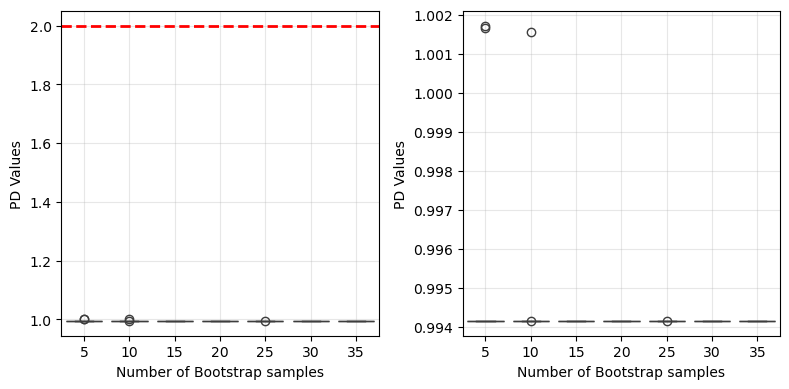

In [92]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

sns.boxplot(data=PD_boot, ax=ax1)
ax1.axhline(y=PDNO, color='r', linestyle='--', linewidth=2)
x_labels = ['5', '10', '15', '20', '25', '30', '35']
ax1.set_xticks(range(len(x_labels)), x_labels)
ax1.set_xlabel('Number of Bootstrap samples')
ax1.set_ylabel('PD Values')
ax1.grid(True, alpha=0.3)

sns.boxplot(data=PD_boot, ax=ax2)
ax2.set_xticks(range(len(x_labels)), x_labels)
ax2.set_xlabel('Number of Bootstrap samples')
ax2.set_ylabel('PD Values')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f'E:/desktop/javadi-soleimani/15 assets/figures_CNN3/PD_compare.jpg')
plt.show()